### Imports

In [ ]:
pip install sentinelhub

In [ ]:
pip install segmentation_models_pytorch

In [ ]:
pip install albumentations

In [ ]:
pip install wandb

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import torchvision.transforms as T
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import importlib.util
import albumentations as A
from albumentations.pytorch import ToTensorV2

### Preparing dataset

In [6]:
import importlib.util
import sys
from pathlib import Path

def load_module(name, path):
    path = Path(path).resolve()
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

In [8]:
# testing that data import works

flood_dataset = load_module("flood_dataset", "scripts/data_model/flood_dataset.py")
FloodDataset = flood_dataset.FloodDataset
plot_sample = flood_dataset.plot_sample

train_transform = A.Compose([
    #A.Resize(32, 32),
    ToTensorV2()
])

train_dataset = FloodDataset("./Data/Split/train_split.json", transform=train_transform)
test_dataset = FloodDataset("./Data/Split/test_split.json", transform=train_transform)
boris_dataset = FloodDataset("./Data_Boris/Split/tile_patch_pairs.json", transform=train_transform)


print(f"Train Dataset: {len(train_dataset)}, Test Dataset: {len(test_dataset)}, Boris Dataset: {len(boris_dataset)}")

Train Dataset: 11900, Test Dataset: 2550, Boris Dataset: 1446


In [ ]:
for i in range(212,220):
    print (i)
    image, mask = train_dataset[i]
    plot_sample(image_tensor = image, mask_tensor = mask)

In [8]:
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

def inspect_sample(dataset, model, metrics, idx: int, class_colors=None, device='cpu'):
    """
    Inspect a single sample from the dataset with metrics and plots.
    """
    model.eval()
    model.to(device)

    # Load and move data to device
    image, gt_mask = dataset[idx]
    image = image.to(device).unsqueeze(0)
    gt_mask = gt_mask.to(device)

    # Inference
    with torch.no_grad():
        output = model(image)
        if isinstance(output, dict):  # handle torchvision models
            output = output["out"]
        pred_mask = torch.argmax(output.squeeze(0), dim=0)

    # Update metrics
    metrics.reset()
    metrics.update(pred_mask.unsqueeze(0), gt_mask.unsqueeze(0))
    results = metrics.all_metrics()

    # Convert to numpy
    image_np = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    gt_mask_np = gt_mask.cpu().numpy()
    pred_mask_np = pred_mask.cpu().numpy()

    # Color map
    if class_colors is None:
        class_colors = ["#c8c8c8", "blue", "red", "green"]

    cmap = mcolors.ListedColormap(class_colors)

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(image_np)
    axs[0].set_title("RGB Image")
    axs[0].axis("off")

    axs[1].imshow(gt_mask_np, cmap=cmap, vmin=0, vmax=len(class_colors)-1)
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis("off")

    axs[2].imshow(pred_mask_np, cmap=cmap, vmin=0, vmax=len(class_colors)-1)
    axs[2].set_title("Predicted Mask")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()

    # Print metrics
    print(f"📊 Metrics for sample index {idx}")
    for class_id, class_metrics in results.items():
        print(f"{class_id}: {class_metrics}")


In [17]:
percentage = train_dataset.calculate_water_pixel_percentage(1)
print(f"Water pixel percentage: {percentage:.2f}%")

Scanning masks for water pixels...
Water pixel percentage: 9.38%


In [18]:
percentage = test_dataset.calculate_water_pixel_percentage(1)
print(f"Water pixel percentage: {percentage:.2f}%")

Scanning masks for water pixels...
Water pixel percentage: 9.61%


In [22]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

for images, masks in train_loader:
    print(images.shape, masks.shape)
    break

torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256])


In [ ]:
# Classes freq

import torch
from collections import Counter
from tqdm import tqdm

def calculate_class_distribution(dataset, num_classes):
    """
    Calculate number of pixels per class in a dataset.

    Args:
        dataset (torch.utils.data.Dataset): Dataset returning (image, mask).
        num_classes (int): Total number of classes.

    Returns:
        torch.Tensor: Frequencies of each class in the dataset.
    """
    pixel_counts = torch.zeros(num_classes, dtype=torch.long)

    for _, mask in tqdm(dataset, desc="Counting pixels per class"):
        if isinstance(mask, torch.Tensor):
            mask = mask.cpu().numpy()
        for cls in range(num_classes):
            pixel_counts[cls] += (mask == cls).sum()

    total_pixels = pixel_counts.sum()
    class_frequencies = pixel_counts.float() / total_pixels

    return class_frequencies, pixel_counts


frequencies, pixel_counts = calculate_class_distribution(train_dataset,4)

# Inverse frequency weighting
class_weights = 1.0 / (frequencies + 1e-6)

# Normalize if needed
class_weights = class_weights / class_weights.sum()

print("Class Frequencies:", frequencies)
print("Class Weights:", class_weights)

### Model prep

In [19]:
training = load_module("training", "scripts/model_training/training.py")
model1 = load_module("model1", "scripts/models/deeplab.py")
model2 = load_module("model2", "scripts/models/fcn_resnet50.py")
model3 = load_module("model3", "scripts/models/unet.py")

#IMPORT TRAINING RELATED FUNCTIONS
train_model = training.train_model
test_model = training.test_model

#IMPORT MODEL-1
DeepLabMobileNet = model1.DeepLabMobileNet

#IMPORT MODEL-2
FcnResnet50 = model2.FcnResnet50

#IMPORT MODEL-3
UnetMobileNetV2 = model3.UnetMobileNetV2


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [59]:
# Data Augmentation - simple

train_transform = A.Compose([
    A.Resize(64, 64),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(64, 64),
    ToTensorV2()
])


# Data Augmentation - more advanced


train_transform_advanced = A.Compose([

    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ], p=0.7),

    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.4, p=0.5),  # from articles
    A.RandomGamma(gamma_limit=(80, 150), p=0.4),  # gamma range ~[0.5, 1.5]

   # A.OneOf([
   #     A.GaussNoise(var_limit=(10, 50), p=0.3),
   #     A.ISONoise(p=0.3),
   # ], p=0.4),

    A.RandomScale(scale_limit=0.1, p=0.3),  # simulate sensor resolution variation

    A.Normalize(),  # standardize inputs (use custom mean/std if needed)
    A.Resize(64, 64),
    ToTensorV2()
])



train_transform_soft = A.Compose([

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),

    A.RandomBrightnessContrast(
        brightness_limit=0.1,  # reduced from 0.2
        contrast_limit=0.2,    # reduced from 0.4
        p=0.3
    ),

    A.RandomGamma(gamma_limit=(90, 120), p=0.2),  # narrower, realistic range

    # A slight noise addition can simulate atmospheric effects
    A.GaussNoise(p=0.2),

    A.Resize(64, 64),  # resizing before normalize to avoid interpolation on normalized data
    A.Normalize(),
    ToTensorV2()
])



train_transform_soft2 = A.Compose([

    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ], p=0.7),

   
    #A.RandomBrightnessContrast(
    #    brightness_limit=0.1,  # reduced from 0.2
    #    contrast_limit=0.2,    # reduced from 0.4
    #    p=0.3
    #),

    #A.RandomGamma(gamma_limit=(90, 120), p=0.2),  # narrower, realistic range

    # A slight noise addition can simulate atmospheric effects
    #A.GaussNoise(p=0.2),

    A.Resize(64, 64),  # resizing before normalize to avoid interpolation on normalized data
    A.Normalize(),
    ToTensorV2()
])



train_transform_tuned = A.Compose([
    
    A.OneOf([
        A.HorizontalFlip(p=0.5),
       # A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ], p=0.3),

   # A.RandomBrightnessContrast(
   #     brightness_limit=0.05,
   #     contrast_limit=0.1,
   #     p=0.2
   # ),

   # A.RandomShadow(p=0.2),   # simulate cloud/shadow occlusion
   # A.RandomFog(p=0.2),      # simulate atmospheric haze

    A.Resize(64, 64),      # preserve more spatial info than 64x64
    A.Normalize(),
    ToTensorV2()
])

### Model 1

In [21]:
# Config for training and testing
config1 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 64, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 6,
    'fraction': 1,
    'val_frequency': 3,
    'debug_mode': True,
    'patience': 3,
    'model_name': "Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k",
    'subset_size': 3000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 1.0, 0.3, 0.3]
}

# Train the model

trainer1 = train_model(config1)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

test/acc,▁
test/dice_1,▁
test/iou_1,▁
test/loss,▁
test/miou,▁
test/precision_1,▁
test/recall_1,▁
test/acc,0.78998
test/dice_1,0.04415
test/iou_1,0.02257
test/loss,0.87686


Training with batch size: 64
Epoch 0/6:
--- Training epoch 0 ---


Train: 100%|██████████| 47/47 [06:00<00:00,  7.66s/it]


Epoch 0 Training Loss: 2221.3993048667908
Training Metrics: Focus (class 1) → IoU: 0.266, Dice: 0.421, Precision: 0.285, Recall: 0.802
Global → Acc: 0.679, mIoU: 0.238, Dice: 0.679, Prec: 0.679, Recall: 0.679
--- Validating epoch 0 ---


...

Train: 100%|██████████| 47/47 [05:59<00:00,  7.66s/it]


Epoch 00005: reducing learning rate of group 0 to 5.0000e-04.
Epoch 4 Training Loss: 1077.5177915096283
Training Metrics: Focus (class 1) → IoU: 0.551, Dice: 0.711, Precision: 0.594, Recall: 0.885
Global → Acc: 0.915, mIoU: 0.560, Dice: 0.915, Prec: 0.915, Recall: 0.915
Epoch 5/6:
--- Training epoch 5 ---


Train: 100%|██████████| 47/47 [05:50<00:00,  7.45s/it]


Epoch 5 Training Loss: 991.2316081523895
Training Metrics: Focus (class 1) → IoU: 0.622, Dice: 0.767, Precision: 0.667, Recall: 0.902
Global → Acc: 0.932, mIoU: 0.599, Dice: 0.932, Prec: 0.932, Recall: 0.932


epoch,▁▂▄▅▇█
train/acc,▁▇▇███
train/dice_1,▁▆▆▇▇█
train/iou_1,▁▅▆▇▇█
train/loss,█▄▃▂▁▁
train/miou,▁▄█▆▇█
train/precision_1,▁▅▆▇▇█
train/recall_1,▁▄▅▆▇█
val/acc,█▁
val/dice_1,█▁
val/iou_1,█▁


In [23]:
test_loss1, test_metric1 = test_model(config1, trainer=trainer1)

CUDA (GPU) is available.
Testing the model...


Model name... Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k


Test: 100%|██████████| 40/40 [04:54<00:00,  7.36s/it]

Test Metrics: Focus (class 1) → IoU: 0.662, Dice: 0.796, Precision: 0.755, Recall: 0.842
Global → Acc: 0.941, mIoU: 0.594, Dice: 0.941, Prec: 0.941, Recall: 0.941


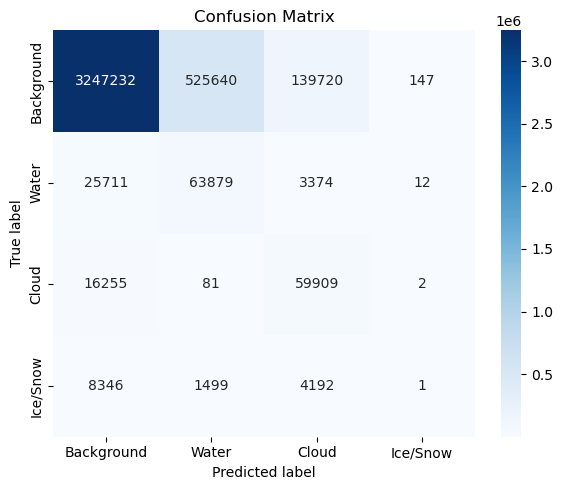

In [14]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric1.plot_confusion_matrix(class_names=class_names)

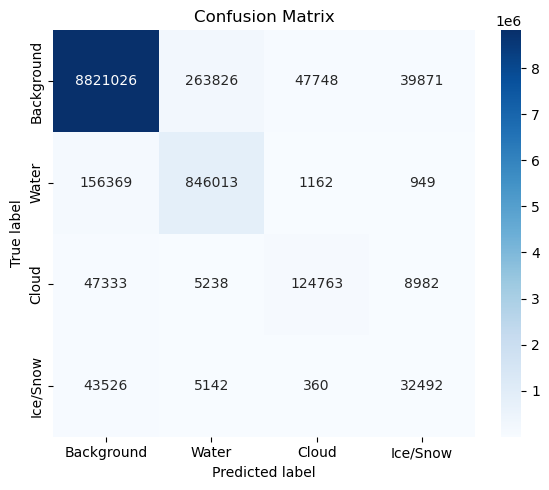

In [24]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric1.plot_confusion_matrix(class_names=class_names)

In [15]:
test_metric1.get_stats(1)

(tensor(63879), tensor(527220), tensor(29097), tensor(3475804))

In [17]:
test_metric1.all_metrics()

{0: {'IoU': 0.8193767666816711,
  'Dice': 0.9007225036621094,
  'Precision': 0.9847425818443298,
  'Recall': 0.8299127817153931},
 1: {'IoU': 0.10299808531999588,
  'Dice': 0.18676021695137024,
  'Precision': 0.10806819051504135,
  'Recall': 0.6870482563972473},
 2: {'IoU': 0.26800963282585144,
  'Dice': 0.4227249324321747,
  'Precision': 0.28914308547973633,
  'Recall': 0.7857227325439453},
 3: {'IoU': 7.04274934832938e-05,
  'Dice': 0.00014084507711231709,
  'Precision': 0.006172839552164078,
  'Recall': 7.123521936591715e-05}}

In [18]:
test_metric1.global_metrics()

{'Overall Accuracy': 0.8230031728744507,
 'Overall Precision': 0.8230031728744507,
 'Overall Recall': 0.8230031728744507,
 'Overall Dice': 0.8230031728744507,
 'Mean IoU': 0.2976137399673462}

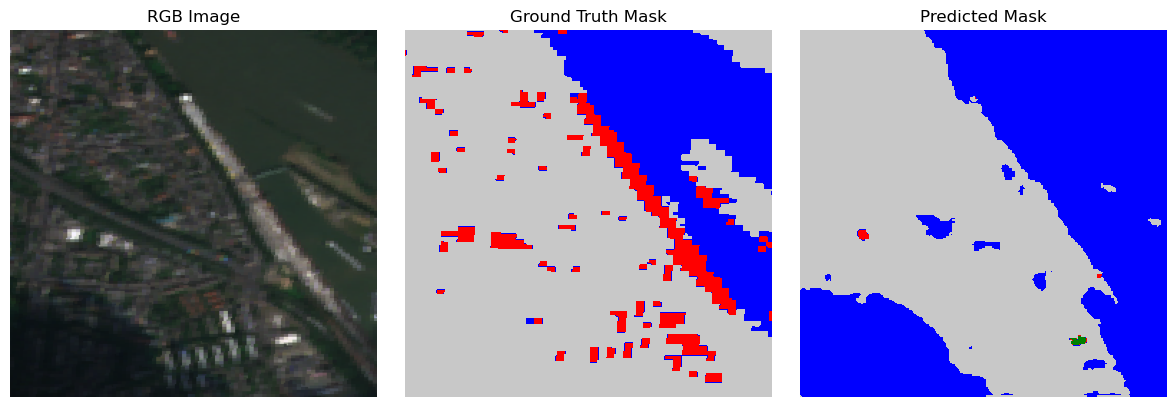

📊 Metrics for sample index 202
0: {'IoU': 0.6446846723556519, 'Dice': 0.7839614152908325, 'Precision': 0.8963234424591064, 'Recall': 0.696632444858551}
1: {'IoU': 0.49775221943855286, 'Dice': 0.6646656394004822, 'Precision': 0.49821335077285767, 'Recall': 0.9981439709663391}
2: {'IoU': 0.01200387254357338, 'Dice': 0.023722976446151733, 'Precision': 1.0, 'Recall': 0.01200387254357338}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [26]:
import torch
model1 = UnetMobileNetV2(num_classes=4)
model1.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3kbest.pth", map_location='cpu'))
model1.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model1, 
               test_metric1, 
               idx=202, device='cuda')

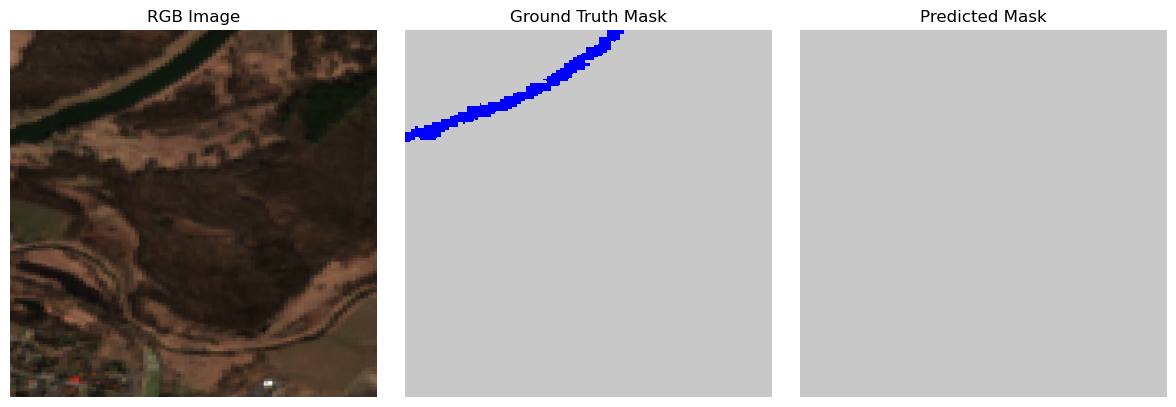

📊 Metrics for sample index 205
0: {'IoU': 0.977691650390625, 'Dice': 0.9887199997901917, 'Precision': 0.977691650390625, 'Recall': 1.0}
1: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [34]:
model1 = UnetMobileNetV2(num_classes=4)
model1.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3kbest.pth", map_location='cpu'))
model1.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model1, 
               test_metric1, 
               idx=205, device='cuda')

### Model 2

In [28]:
# Model with more advanced augmentation used

# Config for training and testing
config2 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/test_Split/val_split.json",
    'train_split':"./Data/test_Split/train_split.json",
    'test_split':"./Data/test_Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform_advanced,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 64, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 3,
    'fraction': 1,
    'val_frequency': 1,
    'debug_mode': True,
    'patience': 3,
    'model_name': "Adam+Weights_loss+Adap_lr+Advanced augment",
    'subset_size': 1000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 1.0, 0.3, 0.3]
}

# Train the model

trainer2 = train_model(config2)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 1000
Validation dataset length: 1000
Test dataset length: 1000
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

Training with batch size: 64
Epoch 0/3:
--- Training epoch 0 ---


Train: 100%|██████████| 16/16 [02:39<00:00,  9.94s/it]


Epoch 0 Training Loss: 954.3809490203857
Training Metrics: Focus (class 1) → IoU: 0.030, Dice: 0.059, Precision: 0.033, Recall: 0.274
Global → Acc: 0.704, mIoU: 0.188, Dice: 0.704, Prec: 0.704, Recall: 0.704
--- Validating epoch 0 ---


Evaluate: 100%|██████████| 16/16 [02:30<00:00,  9.40s/it]


...

Train: 100%|██████████| 16/16 [02:39<00:00,  9.95s/it]


Epoch 2 Training Loss: 643.931266784668
Training Metrics: Focus (class 1) → IoU: 0.069, Dice: 0.130, Precision: 0.120, Recall: 0.141
Global → Acc: 0.947, mIoU: 0.255, Dice: 0.947, Prec: 0.947, Recall: 0.947
--- Validating epoch 2 ---


Evaluate: 100%|██████████| 16/16 [02:31<00:00,  9.49s/it]


Epoch 2 Validation Loss: 995.7011294364929
Validation Metrics: Focus (class 1) → IoU: 0.011, Dice: 0.023, Precision: 0.012, Recall: 0.417
Global → Acc: 0.413, mIoU: 0.111, Dice: 0.413, Prec: 0.413, Recall: 0.413
Early stopping counter: 1/3
✅ Model saved to models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Advanced augmentlast.pth


epoch,▁▅█
train/acc,▁██
train/dice_1,▁█▇
train/iou_1,▁█▇
train/loss,█▂▁
train/miou,▁██
train/precision_1,▁█▆
train/recall_1,█▁▂
val/acc,▆█▁
val/dice_1,▃█▁
val/iou_1,▃█▁


In [29]:
test_loss2, test_metric2 = test_model(config2, trainer=trainer2)

CUDA (GPU) is available.
Testing the model...


Model name... Adam+Weights_loss+Adap_lr+Advanced augment


Test: 100%|██████████| 16/16 [02:29<00:00,  9.33s/it]

Test Metrics: Focus (class 1) → IoU: 0.018, Dice: 0.036, Precision: 0.019, Recall: 0.447
Global → Acc: 0.413, mIoU: 0.112, Dice: 0.413, Prec: 0.413, Recall: 0.413


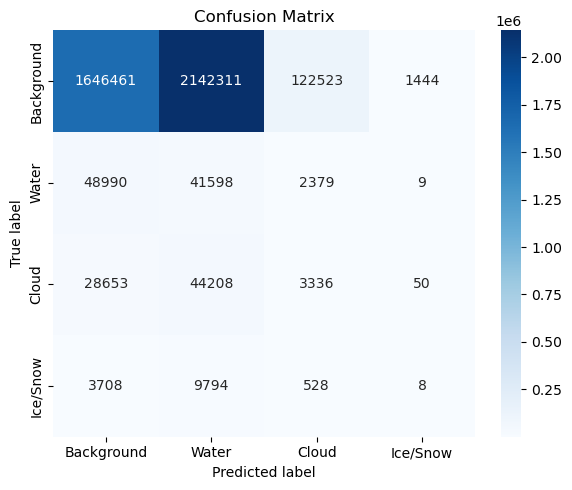

In [30]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric2.plot_confusion_matrix(class_names=class_names)

In [31]:
test_metric2.all_metrics()

{0: {'IoU': 0.41222432255744934,
  'Dice': 0.583794355392456,
  'Precision': 0.9529167413711548,
  'Recall': 0.4207949936389923},
 1: {'IoU': 0.018170706927776337,
  'Dice': 0.03569284826517105,
  'Precision': 0.01858787052333355,
  'Recall': 0.44740578532218933},
 2: {'IoU': 0.01654130034148693,
  'Dice': 0.03254427760839462,
  'Precision': 0.02590746060013771,
  'Recall': 0.04375253990292549},
 3: {'IoU': 0.0005147673655301332,
  'Dice': 0.001029005041345954,
  'Precision': 0.005294506903737783,
  'Recall': 0.0005698817549273372}}

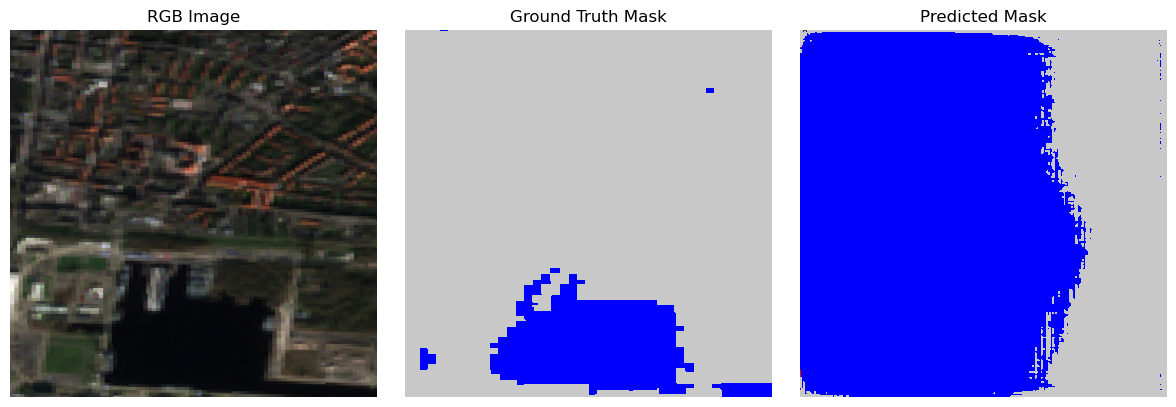

📊 Metrics for sample index 213
0: {'IoU': 0.3105870187282562, 'Dice': 0.4739662706851959, 'Precision': 0.928666353225708, 'Recall': 0.31817784905433655}
1: {'IoU': 0.148269385099411, 'Dice': 0.2582484185695648, 'Precision': 0.15277324616909027, 'Recall': 0.834145188331604}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [32]:
import torch
model2 = UnetMobileNetV2(num_classes=4)
model2.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Advanced augmentbest.pth", map_location='cpu'))
model2.to("cuda")  # or "cpu"

# Inspect
inspect_sample(train_dataset, 
               model2, 
               test_metric2, 
               idx=213, device='cuda')

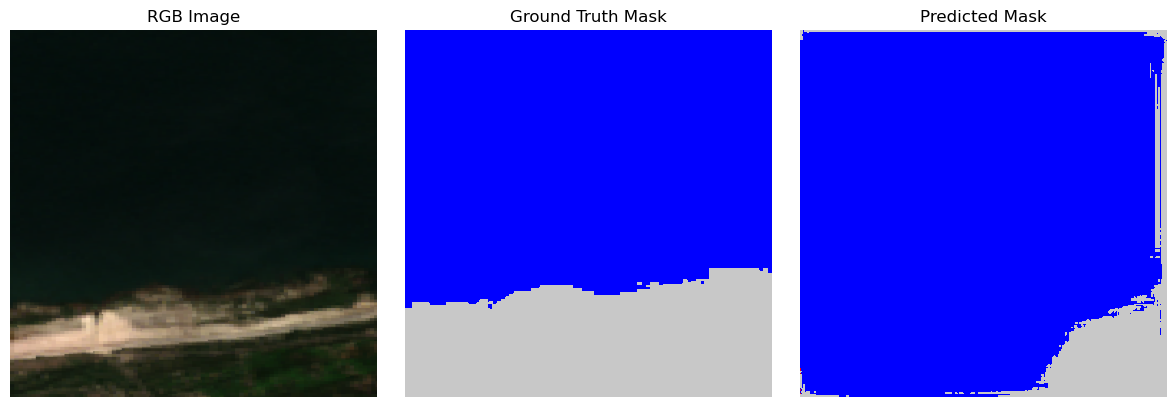

📊 Metrics for sample index 219
0: {'IoU': 0.23859886825084686, 'Dice': 0.38527223467826843, 'Precision': 0.7927143573760986, 'Recall': 0.25447583198547363}
1: {'IoU': 0.7411733865737915, 'Dice': 0.8513492941856384, 'Precision': 0.7572396397590637, 'Recall': 0.9721705317497253}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [33]:
model2 = UnetMobileNetV2(num_classes=4)
model2.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Advanced augmentbest.pth", map_location='cpu'))
model2.to("cuda")  # or "cpu"

# Inspect
inspect_sample(train_dataset, 
               model2, 
               test_metric2, 
               idx=219, device='cuda')

### Model 3

In [39]:
# Not that agressive augmentation


# Model with more advanced augmentation used

# Config for training and testing
config3 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/test_Split/val_split.json",
    'train_split':"./Data/test_Split/train_split.json",
    'test_split':"./Data/test_Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform_soft,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 64, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 3,
    'fraction': 1,
    'val_frequency': 1,
    'debug_mode': True,
    'patience': 3,
    'model_name': "Adam+Weights_loss+Adap_lr+Soft augment",
    'subset_size': 1000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 1.0, 0.3, 0.3]
}

# Train the model

trainer3 = train_model(config3)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 1000
Validation dataset length: 1000
Test dataset length: 1000
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

test/acc,▁
test/dice_1,▁
test/iou_1,▁
test/loss,▁
test/miou,▁
test/precision_1,▁
test/recall_1,▁
test/acc,0.41294
test/dice_1,0.03569
test/iou_1,0.01817
test/loss,1.01444


Training with batch size: 64
Epoch 0/3:
--- Training epoch 0 ---


Train: 100%|██████████| 16/16 [02:31<00:00,  9.47s/it]


Epoch 0 Training Loss: 882.5321321487427
Training Metrics: Focus (class 1) → IoU: 0.010, Dice: 0.021, Precision: 0.013, Recall: 0.051
Global → Acc: 0.797, mIoU: 0.209, Dice: 0.797, Prec: 0.797, Recall: 0.797
--- Validating epoch 0 ---


...

Train: 100%|██████████| 16/16 [02:27<00:00,  9.20s/it]


Epoch 2 Training Loss: 642.2191138267517
Training Metrics: Focus (class 1) → IoU: 0.001, Dice: 0.001, Precision: 0.016, Recall: 0.001
Global → Acc: 0.961, mIoU: 0.371, Dice: 0.961, Prec: 0.961, Recall: 0.961
--- Validating epoch 2 ---


Evaluate: 100%|██████████| 16/16 [02:13<00:00,  8.33s/it]

Epoch 2 Validation Loss: 1251.6423177719116
Validation Metrics: Focus (class 1) → IoU: 0.000, Dice: 0.001, Precision: 0.010, Recall: 0.000
Global → Acc: 0.385, mIoU: 0.133, Dice: 0.385, Prec: 0.385, Recall: 0.385
Early stopping counter: 1/3
✅ Model saved to models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Soft augmentlast.pth


epoch,▁▅█
train/acc,▁██
train/dice_1,█▂▁
train/iou_1,█▂▁
train/loss,█▂▁
train/miou,▁▆█
train/precision_1,▁█▇
train/recall_1,█▁▁
val/acc,██▁
val/dice_1,█▆▁
val/iou_1,█▆▁


### Model 4

In [11]:
# Not that agressive augmentation


# Model with more advanced augmentation used

# Config for training and testing
config4 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/test_Split/val_split.json",
    'train_split':"./Data/test_Split/train_split.json",
    'test_split':"./Data/test_Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform_soft2,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 64, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 3,
    'fraction': 1,
    'val_frequency': 1,
    'debug_mode': True,
    'patience': 3,
    'model_name': "Adam+Weights_loss+Adap_lr+Soft3 augment",
    'subset_size': 1000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 1.0, 0.3, 0.3]
}

# Train the model

trainer4 = train_model(config4)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 1000
Validation dataset length: 1000
Test dataset length: 1000
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

ERROR: ld.so: object '/opt/conda/lib/libmkl_def.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_avx2.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_core.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_lp64.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_thread.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.


Training with batch size: 64
Epoch 0/3:
--- Training epoch 0 ---


Train: 100%|██████████| 16/16 [03:17<00:00, 12.35s/it]


Epoch 0 Training Loss: 996.1306037902832
Training Metrics: Focus (class 1) → IoU: 0.024, Dice: 0.047, Precision: 0.028, Recall: 0.143
Global → Acc: 0.631, mIoU: 0.167, Dice: 0.631, Prec: 0.631, Recall: 0.631
--- Validating epoch 0 ---


...

Train: 100%|██████████| 16/16 [02:06<00:00,  7.88s/it]


Epoch 2 Training Loss: 638.8495254516602
Training Metrics: Focus (class 1) → IoU: 0.092, Dice: 0.169, Precision: 0.130, Recall: 0.242
Global → Acc: 0.940, mIoU: 0.344, Dice: 0.940, Prec: 0.940, Recall: 0.940
--- Validating epoch 2 ---


Evaluate: 100%|██████████| 16/16 [02:44<00:00, 10.28s/it]

Epoch 2 Validation Loss: 819.4953508377075
Validation Metrics: Focus (class 1) → IoU: 0.017, Dice: 0.033, Precision: 0.018, Recall: 0.199
Global → Acc: 0.798, mIoU: 0.204, Dice: 0.798, Prec: 0.798, Recall: 0.798
#### Best val_miou 0.20428423583507538 at epoch 2
#### Saving model to models_experiments_1
✅ Model saved to models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Soft3 augmentbest.pth
✅ Model saved to models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Soft3 augmentlast.pth


epoch,▁▅█
train/acc,▁██
train/dice_1,▁█▇
train/iou_1,▁█▇
train/loss,█▂▁
train/miou,▁▅█
train/precision_1,▁█▆
train/recall_1,▁▃█
val/acc,▃▁█
val/dice_1,█▁▆
val/iou_1,█▁▆


In [12]:
test_loss4, test_metric4 = test_model(config4, trainer=trainer4)

CUDA (GPU) is available.
Testing the model...


Model name... Adam+Weights_loss+Adap_lr+Soft3 augment


Test: 100%|██████████| 16/16 [03:23<00:00, 12.69s/it]

Test Metrics: Focus (class 1) → IoU: 0.023, Dice: 0.044, Precision: 0.025, Recall: 0.191
Global → Acc: 0.790, mIoU: 0.204, Dice: 0.790, Prec: 0.790, Recall: 0.790


In [ ]:
import torch
model2 = UnetMobileNetV2(num_classes=4)
model2.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Advanced augmentbest.pth", map_location='cpu'))
model2.to("cuda")  # or "cpu"

# Inspect
inspect_sample(train_dataset, 
               model2, 
               test_metric2, 
               idx=213, device='cuda')

In [ ]:
for i in range(200,220):
    print (i)
    image, mask = test_dataset[i]
    plot_sample(image_tensor = image, mask_tensor = mask)

### New dataset Model with different weights

In [36]:
# Config for training and testing
config2 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 64, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 3,
    'fraction': 1,
    'val_frequency': 1,
    'debug_mode': True,
    'patience': 3,
    'model_name': "Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k+another weights",
    'subset_size': 3000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.7, 0.3, 0.3]
}

# Train the model

trainer2 = train_model(config2)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

test/acc,▁
test/dice_1,▁
test/iou_1,▁
test/loss,▁
test/miou,▁
test/precision_1,▁
test/recall_1,▁
test/acc,0.9287
test/dice_1,0.75109
test/iou_1,0.6014
test/loss,0.40752


Training with batch size: 64
Epoch 0/3:
--- Training epoch 0 ---


Train: 100%|██████████| 47/47 [05:59<00:00,  7.64s/it]


Epoch 0 Training Loss: 1900.212586402893
Training Metrics: Focus (class 1) → IoU: 0.320, Dice: 0.485, Precision: 0.353, Recall: 0.775
Global → Acc: 0.802, mIoU: 0.314, Dice: 0.802, Prec: 0.802, Recall: 0.802
--- Validating epoch 0 ---


...

Train: 100%|██████████| 47/47 [05:52<00:00,  7.50s/it]


Epoch 2 Training Loss: 1259.279508113861
Training Metrics: Focus (class 1) → IoU: 0.525, Dice: 0.688, Precision: 0.586, Recall: 0.834
Global → Acc: 0.911, mIoU: 0.467, Dice: 0.911, Prec: 0.911, Recall: 0.911
--- Validating epoch 2 ---


Evaluate: 100%|██████████| 40/40 [05:25<00:00,  8.13s/it]

Epoch 2 Validation Loss: 1120.6400911808014
Validation Metrics: Focus (class 1) → IoU: 0.442, Dice: 0.613, Precision: 0.482, Recall: 0.840
Global → Acc: 0.883, mIoU: 0.439, Dice: 0.883, Prec: 0.883, Recall: 0.883
Early stopping counter: 1/3
✅ Model saved to models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k+another weightslast.pth


epoch,▁▅█
train/acc,▁██
train/dice_1,▁██
train/iou_1,▁██
train/loss,█▂▁
train/miou,▁█▅
train/precision_1,▁██
train/recall_1,▁▆█
val/acc,▁█▃
val/dice_1,▁█▃
val/iou_1,▁█▃


In [28]:
test_loss2, test_metric2 = test_model(config2, trainer=trainer2)

CUDA (GPU) is available.
Testing the model...


Model name... Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k+another weights


Test: 100%|██████████| 40/40 [06:29<00:00,  9.74s/it]

Test Metrics: Focus (class 1) → IoU: 0.601, Dice: 0.751, Precision: 0.682, Recall: 0.836
Global → Acc: 0.929, mIoU: 0.502, Dice: 0.929, Prec: 0.929, Recall: 0.929


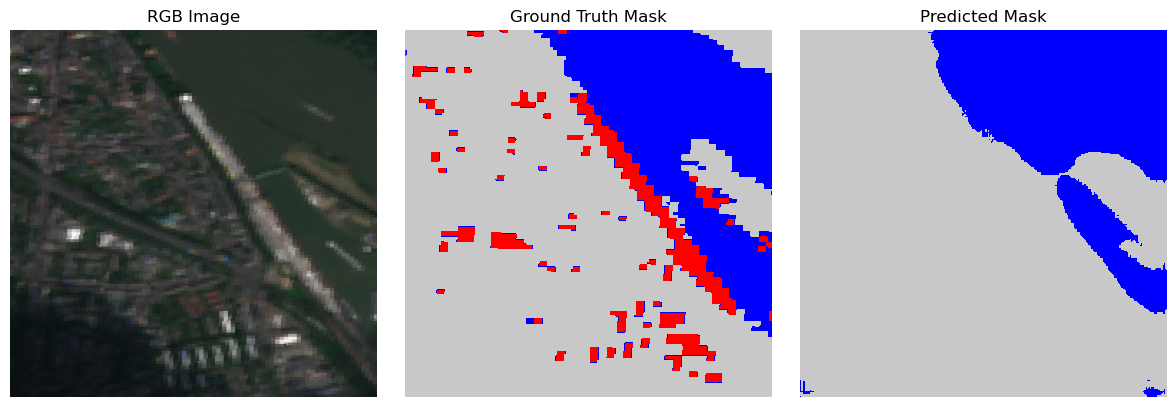

📊 Metrics for sample index 202
0: {'IoU': 0.8403552770614624, 'Dice': 0.9132533073425293, 'Precision': 0.8769437074661255, 'Recall': 0.9526995420455933}
1: {'IoU': 0.7651519179344177, 'Dice': 0.8669530749320984, 'Precision': 0.8337107300758362, 'Recall': 0.9029563665390015}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [30]:
import torch
model2 = UnetMobileNetV2(num_classes=4)
model2.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k+another weightsbest.pth", map_location='cpu'))
model2.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model2, 
               test_metric2, 
               idx=202, device='cuda')

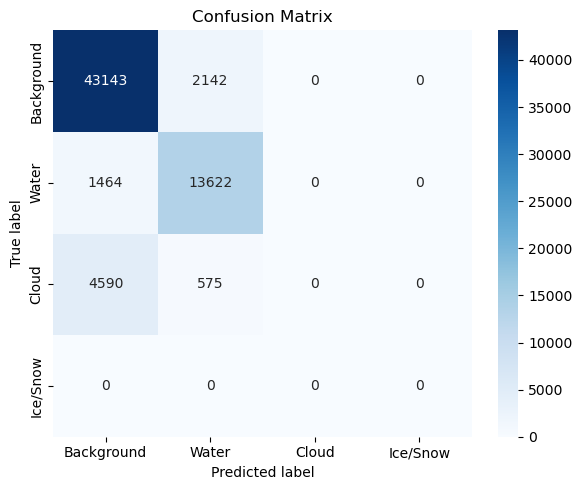

In [31]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric2.plot_confusion_matrix(class_names=class_names)

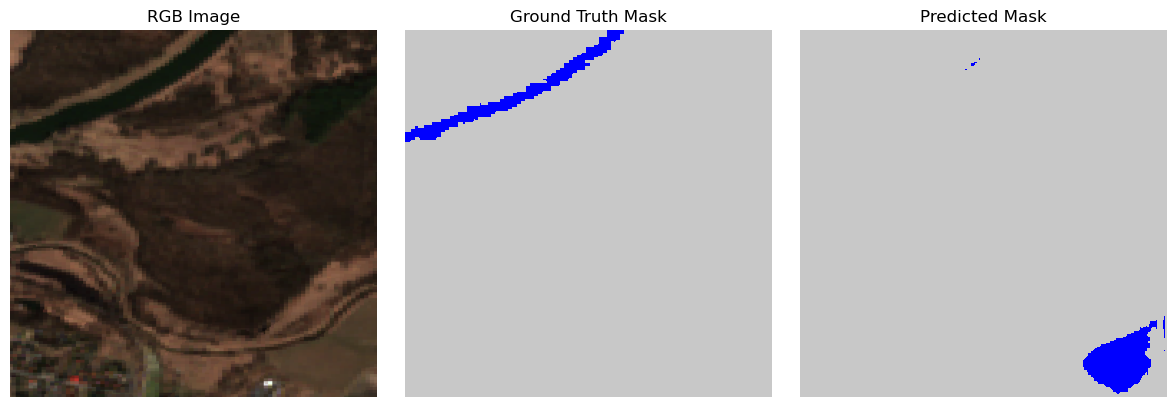

📊 Metrics for sample index 205
0: {'IoU': 0.9554945230484009, 'Dice': 0.977240800857544, 'Precision': 0.977423906326294, 'Recall': 0.9770577549934387}
1: {'IoU': 0.005457025952637196, 'Dice': 0.010854816995561123, 'Precision': 0.01076715998351574, 'Recall': 0.010943912900984287}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [35]:
model2 = UnetMobileNetV2(num_classes=4)
model2.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_Adam+Weights_loss+Adap_lr+Basic augment+new dataset+3k+another weightsbest.pth", map_location='cpu'))
model2.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model2, 
               test_metric2, 
               idx=205, device='cuda')

### Another weights

In [37]:
# Config for training and testing
config3 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 64, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 3,
    'fraction': 1,
    'val_frequency': 1,
    'debug_mode': True,
    'patience': 3,
    'model_name': "Test 1.0 once again",
    'subset_size': 3000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 1.0, 0.3, 0.3]
}

# Train the model

trainer3 = train_model(config3)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

Training with batch size: 64
Epoch 0/3:
--- Training epoch 0 ---


Train: 100%|██████████| 47/47 [05:41<00:00,  7.27s/it]


Epoch 0 Training Loss: 1890.3652892112732
Training Metrics: Focus (class 1) → IoU: 0.307, Dice: 0.469, Precision: 0.336, Recall: 0.780
Global → Acc: 0.807, mIoU: 0.318, Dice: 0.807, Prec: 0.807, Recall: 0.807
--- Validating epoch 0 ---


Evaluate: 100%|██████████| 40/40 [05:02<00:00,  7.55s/it]


...

Train: 100%|██████████| 47/47 [05:47<00:00,  7.40s/it]


Epoch 2 Training Loss: 1251.5785188674927
Training Metrics: Focus (class 1) → IoU: 0.525, Dice: 0.688, Precision: 0.578, Recall: 0.850
Global → Acc: 0.910, mIoU: 0.465, Dice: 0.910, Prec: 0.910, Recall: 0.910
--- Validating epoch 2 ---


Evaluate: 100%|██████████| 40/40 [05:17<00:00,  7.95s/it]

Epoch 2 Validation Loss: 1126.9650916457176
Validation Metrics: Focus (class 1) → IoU: 0.415, Dice: 0.586, Precision: 0.440, Recall: 0.878
Global → Acc: 0.875, mIoU: 0.445, Dice: 0.875, Prec: 0.875, Recall: 0.875
Early stopping counter: 2/3
✅ Model saved to models_experiments_1/unet_mobilenetv3_Test 1.0 once againlast.pth


epoch,▁▅█
train/acc,▁▇█
train/dice_1,▁▇█
train/iou_1,▁▇█
train/loss,█▂▁
train/miou,▁▇█
train/precision_1,▁▇█
train/recall_1,▁▇█
val/acc,▄█▁
val/dice_1,▅█▁
val/iou_1,▅█▁


In [53]:
# 1.0 + bigger batches for more stability
config4 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 4,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "0.9 + 128 batches + 6k",
    'subset_size': 6000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer4 = train_model(config4)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 6000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

Training with batch size: 128
Epoch 0/4:
--- Training epoch 0 ---


Train: 100%|██████████| 47/47 [11:42<00:00, 14.95s/it]


Epoch 0 Training Loss: 4385.497842788696
Training Metrics: Focus (class 1) → IoU: 0.253, Dice: 0.404, Precision: 0.263, Recall: 0.866
Global → Acc: 0.622, mIoU: 0.241, Dice: 0.622, Prec: 0.622, Recall: 0.622
--- Validating epoch 0 ---


Evaluate: 100%|██████████| 20/20 [04:49<00:00, 14.49s/it]


...

Evaluate: 100%|██████████| 20/20 [04:45<00:00, 14.28s/it]


Epoch 2 Validation Loss: 1004.7618399858475
Validation Metrics: Focus (class 1) → IoU: 0.588, Dice: 0.741, Precision: 0.683, Recall: 0.808
Global → Acc: 0.929, mIoU: 0.571, Dice: 0.929, Prec: 0.929, Recall: 0.929
#### Best val_miou 0.5712136626243591 at epoch 2
#### Saving model to models_experiments_1
✅ Model saved to models_experiments_1/unet_mobilenetv3_0.9 + 128 batches + 6kbest.pth
Epoch 3/4:
--- Training epoch 3 ---


Train: 100%|██████████| 47/47 [11:52<00:00, 15.16s/it]

Epoch 3 Training Loss: 1944.4200630187988
Training Metrics: Focus (class 1) → IoU: 0.604, Dice: 0.753, Precision: 0.651, Recall: 0.893
Global → Acc: 0.929, mIoU: 0.598, Dice: 0.929, Prec: 0.929, Recall: 0.929


epoch,▁▃▆█
train/acc,▁███
train/dice_1,▁▇██
train/iou_1,▁▆██
train/loss,█▃▂▁
train/miou,▁▅▇█
train/precision_1,▁▇██
train/recall_1,▄▁▆█
val/acc,▁█
val/dice_1,▁█
val/iou_1,▁█


In [54]:
test_loss4, test_metric4 = test_model(config4, trainer=trainer4)

CUDA (GPU) is available.
Testing the model...


Model name... 0.9 + 128 batches + 6k


Test: 100%|██████████| 20/20 [04:43<00:00, 14.20s/it]

Test Metrics: Focus (class 1) → IoU: 0.596, Dice: 0.747, Precision: 0.646, Recall: 0.885
Global → Acc: 0.925, mIoU: 0.580, Dice: 0.925, Prec: 0.925, Recall: 0.925


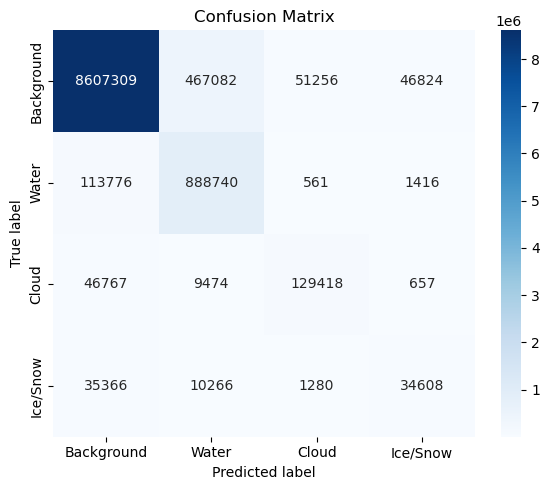

In [55]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric4.plot_confusion_matrix(class_names=class_names)

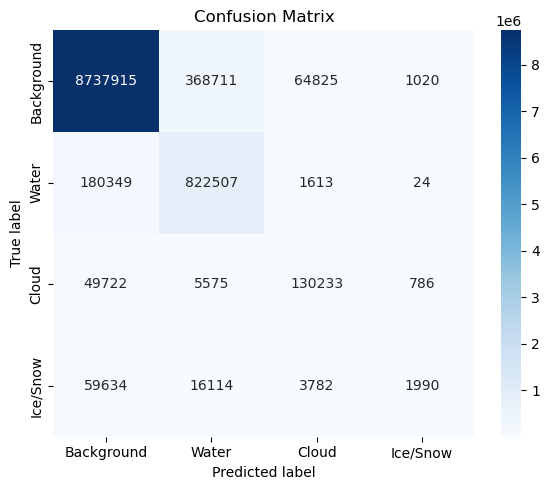

In [41]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric4.plot_confusion_matrix(class_names=class_names)

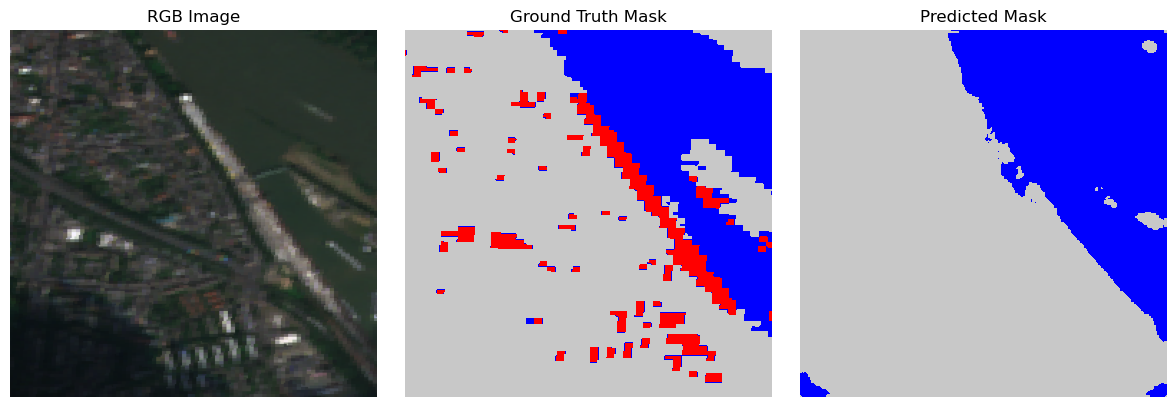

📊 Metrics for sample index 202
0: {'IoU': 0.8464317917823792, 'Dice': 0.9168297648429871, 'Precision': 0.907964825630188, 'Recall': 0.9258694648742676}
1: {'IoU': 0.7565403580665588, 'Dice': 0.8613982200622559, 'Precision': 0.7663498520851135, 'Recall': 0.983362078666687}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [46]:
model4 = UnetMobileNetV2(num_classes=4)
model4.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_0.9 + 128 batchesbest.pth", map_location='cpu'))
model4.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model4, 
               test_metric4, 
               idx=202, device='cuda')

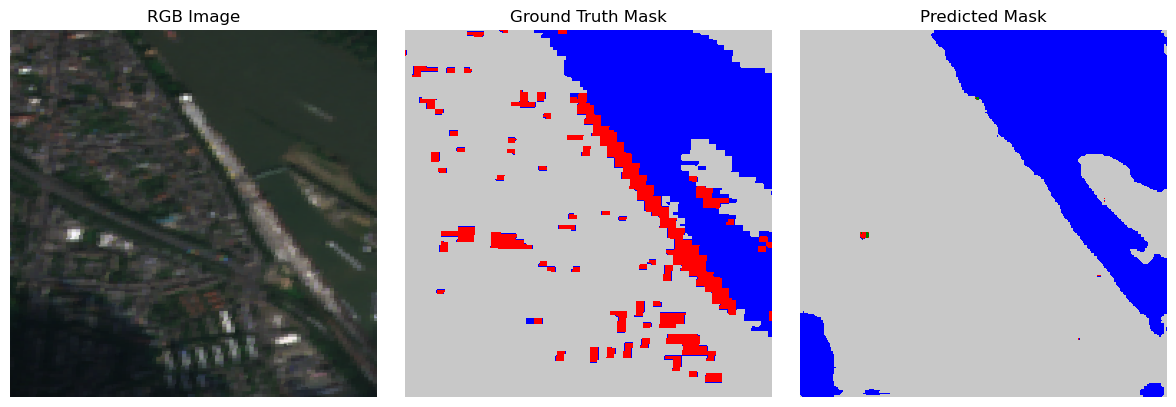

📊 Metrics for sample index 202
0: {'IoU': 0.8326482176780701, 'Dice': 0.9086830615997314, 'Precision': 0.8879802823066711, 'Recall': 0.9303743243217468}
1: {'IoU': 0.7742677927017212, 'Dice': 0.8727744817733765, 'Precision': 0.8010746836662292, 'Recall': 0.9585708379745483}
2: {'IoU': 0.004065827466547489, 'Dice': 0.008098727092146873, 'Precision': 1.0, 'Recall': 0.004065827466547489}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [58]:


model4 = UnetMobileNetV2(num_classes=4)
model4.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_0.9 + 128 batches + 6kbest.pth", map_location='cpu'))
model4.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model4, 
               test_metric4, 
               idx=202, device='cuda')

#### Trying augmentation on new & bigger dataset

In [60]:
# Do not use augmentation

# 1.0 + bigger batches for more stability
config5 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform_tuned,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 4,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "0.9 + 128 batches + 6k + soft augment",
    'subset_size': 6000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer5 = train_model(config5)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 6000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

test/acc,▁
test/dice_1,▁
test/iou_1,▁
test/loss,▁
test/miou,▁
test/precision_1,▁
test/recall_1,▁
test/acc,0.92487
test/dice_1,0.74682
test/iou_1,0.59594
test/loss,0.35164


Training with batch size: 128
Epoch 0/4:
--- Training epoch 0 ---


Train: 100%|██████████| 47/47 [11:33<00:00, 14.76s/it]


Epoch 0 Training Loss: 4423.839184761047
Training Metrics: Focus (class 1) → IoU: 0.222, Dice: 0.364, Precision: 0.241, Recall: 0.738
Global → Acc: 0.709, mIoU: 0.232, Dice: 0.709, Prec: 0.709, Recall: 0.709
--- Validating epoch 0 ---


...

Epoch 2 Training Loss: 2735.4735164642334
Training Metrics: Focus (class 1) → IoU: 0.469, Dice: 0.639, Precision: 0.526, Recall: 0.812
Global → Acc: 0.884, mIoU: 0.465, Dice: 0.884, Prec: 0.884, Recall: 0.884
--- Validating epoch 2 ---


Evaluate: 100%|██████████| 20/20 [05:01<00:00, 15.07s/it]


Epoch 2 Validation Loss: 13164.27026462555
Validation Metrics: Focus (class 1) → IoU: 0.000, Dice: 0.001, Precision: 0.203, Recall: 0.000
Global → Acc: 0.526, mIoU: 0.150, Dice: 0.526, Prec: 0.526, Recall: 0.526
Early stopping counter: 1/3
Epoch 3/4:
--- Training epoch 3 ---


Train:  15%|█▍        | 7/47 [01:52<10:40, 16.01s/it]


KeyboardInterrupt: 

In [ ]:
# 1.0 + bigger batches for more stability
config4 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 10,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "0.9 + 128 batches + 6k",
    'subset_size': 6000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer4 = train_model(config4)

In [7]:
training = load_module("training", "scripts/model_training/training.py")
model1 = load_module("model1", "scripts/models/deeplab.py")
#model2 = load_module("model2", "scripts/models/fcn_resnet50.py")
model3 = load_module("model3", "scripts/models/unet.py")
model4 = load_module("model3", "scripts/models/unet_resnet.py")
model5 = load_module("model5", "scripts/models/deeplab+resnet.py")

#IMPORT TRAINING RELATED FUNCTIONS
train_model = training.train_model
test_model = training.test_model

#IMPORT MODEL-1
DeepLabMobileNet = model1.DeepLabMobileNet

#IMPORT MODEL-2
#FcnResnet50 = model2.FcnResnet50

#IMPORT MODEL-3
UnetMobileNetV2 = model3.UnetMobileNetV2

UnetResNet = model4.UnetResNet

DeepLabResNet = model5.DeepLabResNet


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jovyan/.netrc
wandb: Currently logged in as: ovsvc (ovsvc-tu-wien) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:
# Data Augmentation - simple

train_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])



# 1.0 + bigger batches for more stability
config10 = {
    'model':  DeepLabResNet(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_deeplab',
    'results_save_dir': './results_deeplab',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 4,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "DeepLab+ResNet50",
    'subset_size': 3000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer10 = train_model(config10)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /home/jovyan/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:00<00:00, 251MB/s] 


CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: DeepLabResNet(
  (model): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_siz

ERROR: ld.so: object '/opt/conda/lib/libmkl_def.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_avx2.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_core.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_lp64.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_thread.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.


Training with batch size: 128
Epoch 0/4:
--- Training epoch 0 ---


Train:   0%|          | 0/24 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacty of 14.57 GiB of which 4.75 MiB is free. Process 2538767 has 9.90 GiB memory in use. Process 2510919 has 4.66 GiB memory in use. Of the allocated memory 4.45 GiB is allocated by PyTorch, and 93.18 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF